### Importing modules and loading the dataset

In [ ]:
#Importing all the packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('telco_customer_churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'] , errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median() , inplace = True)

df['Churn'] = df['Churn'].map({'Yes':1 , 'No':0})

print("Shape: ", df.shape )


Shape:  (7043, 21)


## Financial Risk Analysis

Here we are calculating the amount of revenue lost in respect to their contract type

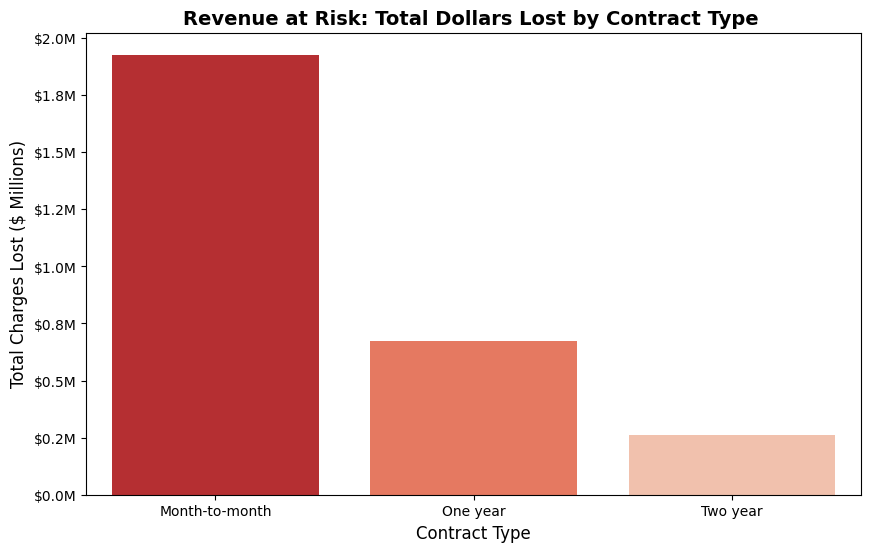

Exact Revenue Lost by Contract
      Contract Formatted_Total
Month-to-month   $1,927,182.25
      One year     $674,991.20
      Two year     $260,753.45


In [157]:
churned_df = df[df['Churn']==1]

revenue_risk = churned_df.groupby('Contract')['TotalCharges'].sum().reset_index()

plt.figure(figsize= (10,6))
ax = sns.barplot(x='Contract' , y='TotalCharges' , data = revenue_risk , palette='Reds_r')


plt.title('Revenue at Risk: Total Dollars Lost by Contract Type ', fontsize= 14, fontweight ='bold')
plt.ylabel('Total Charges Lost ($ Millions)', fontsize=12)
plt.xlabel('Contract Type', fontsize=12)

ylabels = ['${:,.1f}M'.format(y/1000000) for y in ax.get_yticks()]
ax.set_yticklabels(ylabels)

plt.show()

print("Exact Revenue Lost by Contract")
revenue_risk['Formatted_Total'] = revenue_risk['TotalCharges'].apply(lambda x: f"${x:,.2f}")
print(revenue_risk[['Contract', 'Formatted_Total']].to_string(index=False))

### Danger Zone Analysis

We know that Contract Type is bleeding money so here we analyse when the customers are leaving. This the analysis of to find the exact months a customer is most likely to cancel their service 

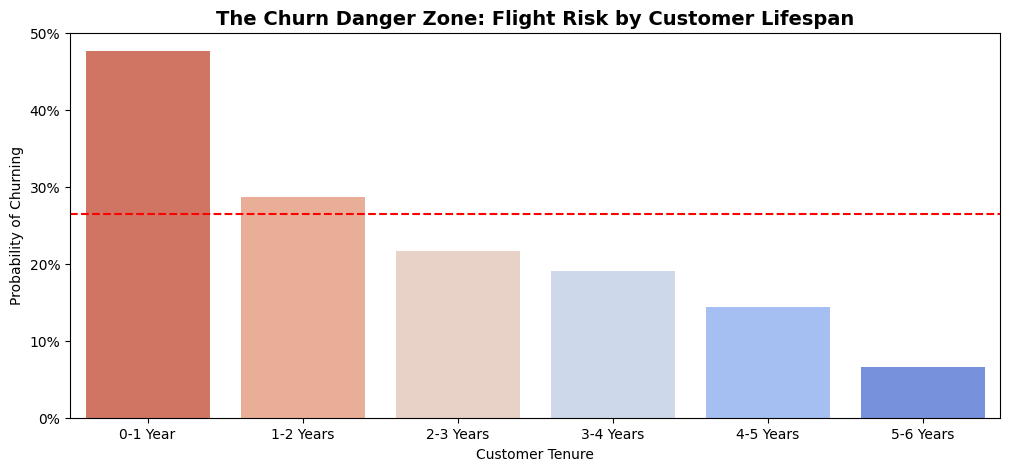

In [158]:
plt.figure(figsize=(12, 5))


df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 36, 48, 60, 72], 
                            labels=['0-1 Year', '1-2 Years', '2-3 Years', '3-4 Years', '4-5 Years', '5-6 Years'])

tenure_churn = df.groupby('Tenure_Group')['Churn'].mean().reset_index()

ax = sns.barplot(x = 'Tenure_Group' , y = 'Churn' , data = tenure_churn , palette= 'coolwarm_r')
plt.title('The Churn Danger Zone: Flight Risk by Customer Lifespan', fontsize=14, fontweight='bold')
plt.ylabel('Probability of Churning')
plt.xlabel('Customer Tenure')

ylabels = ['{:,.0f}%'.format(y*100) for y in ax.get_yticks()]
ax.set_yticklabels(ylabels)
plt.axhline(df['Churn'].mean(), color='red', linestyle='--', label='Average Global Churn Rate')

df.drop('Tenure_Group', axis=1, inplace=True)

### Production PipleLine

Creating a automated pipeline for preprocessing and training models so that we dont have to do it again


In [159]:
X = df.drop(['customerID' , 'Churn'] , axis = 1)
y = df['Churn']

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train.columns if col not in numeric_features]


numeric_transformer = Pipeline(steps = [
    ('imputer' , SimpleImputer(strategy  = 'median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps = [
    ('imputer' , SimpleImputer(strategy= 'constant' , fill_value= 'missing')),
    ('onehot' , OneHotEncoder(handle_unknown= 'ignore' , drop='first'))
])
preprocessor = ColumnTransformer(
    transformers = [
        ('num' , numeric_transformer , numeric_features),
        ('cat', categorical_transformer , categorical_features)
    ]
)
log_pipeline = Pipeline(steps=[
    ('preprocessor' , preprocessor ),
    ( 'classifier' , LogisticRegression(class_weight='balanced' , max_iter=1000, random_state=42))
])

nb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB()) 
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

log_pipeline.fit(X_train, y_train)
nb_pipeline.fit(X_train, y_train)


log_pred = log_pipeline.predict(X_test)
nb_pred = nb_pipeline.predict(X_test)

print("Pipelines trained successfully")

Pipelines trained successfully


### Financial Evaluation Metric

Here we are analysing the impact of three of the machine learning models that we used to predict our churners and how much of a business impact we are getting out of it. 

In [160]:

promo_cost = 50 

avg_ltv = df[df['Churn'] == 1]['TotalCharges'].mean()

def calculate_financial_loss(y_true, y_pred, model_name):
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    wasted_promos = fp * promo_cost
    lost_revenue = fn * avg_ltv
    total_loss = wasted_promos + lost_revenue
    
    total_actual_churners = tp + fn 
    baseline_loss = total_actual_churners * avg_ltv
    net_savings = baseline_loss - total_loss

    print(f"Financial Impact: {model_name} =====")
    print(f"Baseline Loss (If we do nothing): ${baseline_loss:,.2f}")
    print(f"Net Savings Generated ${net_savings:,.2f}")
    print(f"True Positives (Customers Saved): {tp}")
    print(f"False Positives (Wasted $50 Promos): {fp} -> Cost: ${wasted_promos:,.2f}")
    print(f"False Negatives (Missed Churners): {fn} -> Lost Revenue: ${lost_revenue:,.2f}")
    print(f"Total Business Loss: ${total_loss:,.2f}\n")
    print()

print(f"Average Lifetime Value (LTV) of a churned customer: ${avg_ltv:,.2f}\n")

calculate_financial_loss(y_test, log_pred, "Logistic Regression (Balanced Pipeline)")
calculate_financial_loss(y_test, nb_pred, "Naive Bayes (Standard Pipeline)")
calculate_financial_loss(y_test, rf_pred, "Random Forest (Balanced)")

Average Lifetime Value (LTV) of a churned customer: $1,531.80

Financial Impact: Logistic Regression (Balanced Pipeline) =====
Baseline Loss (If we do nothing): $572,891.74
Net Savings Generated $434,466.26
True Positives (Customers Saved): 293
False Positives (Wasted $50 Promos): 287 -> Cost: $14,350.00
False Negatives (Missed Churners): 81 -> Lost Revenue: $124,075.48
Total Business Loss: $138,425.48


Financial Impact: Naive Bayes (Standard Pipeline) =====
Baseline Loss (If we do nothing): $572,891.74
Net Savings Generated $474,551.93
True Positives (Customers Saved): 324
False Positives (Wasted $50 Promos): 435 -> Cost: $21,750.00
False Negatives (Missed Churners): 50 -> Lost Revenue: $76,589.80
Total Business Loss: $98,339.80


Financial Impact: Random Forest (Balanced) =====
Baseline Loss (If we do nothing): $572,891.74
Net Savings Generated $278,182.28
True Positives (Customers Saved): 185
False Positives (Wasted $50 Promos): 104 -> Cost: $5,200.00
False Negatives (Missed Churne

### Financial Feature Importance
Figuring out what is actually driving the churn 

In [161]:

my_data_cleaner = log_pipeline.named_steps['preprocessor']
my_model = log_pipeline.named_steps['classifier']


column_names = preprocessor.get_feature_names_out()
math_weights = my_model.coef_[0]

feature_table = pd.DataFrame()
feature_table['Feature_Name'] = column_names
feature_table['Risk_Weight'] = math_weights

sorted_table = feature_table.sort_values(by='Risk_Weight', ascending=False)

print(" RED FLAGS (Top 5 Drivers Causing Churn):")
print(sorted_table.head(5).to_string(index=False))

print("\nGREEN FLAGS (Top 5 Drivers Preventing Churn):")
print(sorted_table.tail(5).to_string(index=False))


 RED FLAGS (Top 5 Drivers Causing Churn):
                       Feature_Name  Risk_Weight
   cat__InternetService_Fiber optic     1.220706
                  num__TotalCharges     0.473486
           cat__StreamingMovies_Yes     0.422220
cat__PaymentMethod_Electronic check     0.402968
               cat__StreamingTV_Yes     0.396052

GREEN FLAGS (Top 5 Drivers Preventing Churn):
          Feature_Name  Risk_Weight
 cat__PhoneService_Yes    -0.345915
   num__MonthlyCharges    -0.544015
cat__Contract_One year    -0.715807
           num__tenure    -1.143899
cat__Contract_Two year    -1.413550


### Business Activation

Handing out explainable statistics for decision making 


In [162]:

risk_probabilities = nb_pipeline.predict_proba(X)[:, 1]

action_table = df.copy()
action_table['Churn_Risk_Score'] = risk_probabilities

conditions = [
    (action_table['Churn_Risk_Score'] >= 0.75),  
    (action_table['Churn_Risk_Score'] >= 0.40) & (action_table['Churn_Risk_Score'] < 0.75),
    (action_table['Churn_Risk_Score'] < 0.40)
]
tier_names = ['High Risk (Target Immediately)', 'Medium Risk (Monitor)', 'Low Risk (Safe)']
action_table['Risk_Tier'] = np.select(conditions, tier_names, default='Unknown')

tier_summary = action_table.groupby('Risk_Tier').agg(
    Customer_Count=('customerID', 'count'),
    Revenue_At_Risk=('TotalCharges', 'sum')
).reset_index()

tier_summary['Revenue_At_Risk'] = tier_summary['Revenue_At_Risk'].apply(lambda x: f"${x:,.2f}")

print("MARKETING DASHBOARD ===")
print(tier_summary.to_string(index=False))
print("\n")

print("Sample of the 'High Risk' Call List ")
high_risk_list = action_table[action_table['Risk_Tier'] == 'High Risk (Target Immediately)']
print(high_risk_list[['customerID', 'Contract', 'MonthlyCharges', 'Churn_Risk_Score']].head())

MARKETING DASHBOARD ===
                     Risk_Tier  Customer_Count Revenue_At_Risk
High Risk (Target Immediately)            3589   $6,230,988.80
               Low Risk (Safe)            3198   $8,946,469.55
         Medium Risk (Monitor)             256     $878,710.35


Sample of the 'High Risk' Call List 
   customerID        Contract  MonthlyCharges  Churn_Risk_Score
0  7590-VHVEG  Month-to-month           29.85          0.998831
2  3668-QPYBK  Month-to-month           53.85          0.992964
4  9237-HQITU  Month-to-month           70.70          0.999994
5  9305-CDSKC  Month-to-month           99.65          0.999997
6  1452-KIOVK  Month-to-month           89.10          0.997511
